# Notebook 03 — Validation & Model Evaluation

Training loss tells you how well a model memorises its training data — not whether it
can predict new observations. This notebook shows how to:

- Hold out a future test window with `train_test_split`
- Track train vs validation loss during training with `val_data`
- Use early stopping to prevent overfitting
- Evaluate forecasts with `mse`, `rmse`, `mae`, and `r2_score`
- Compare `NODE` against `CustomDerivatives` on the same dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.integrate import solve_ivp
import pyUDE as ude

np.random.seed(42)
torch.manual_seed(42)
print(f'pyUDE {ude.__version__}')

pyUDE 0.0.2


## 1 — Generate Data: Damped Oscillator

The damped harmonic oscillator has the exact solution we can compare against:

```
dx/dt = y
dy/dt = -ω²x - 2γy
```

with `ω = 2.0`, `γ = 0.3`. We will pretend we only know `ω` and must learn `γ` from data.

In [2]:
omega, gamma = 2.0, 0.3

def damped_osc(t, u):
    x, y = u
    return [y, -omega**2 * x - 2*gamma * y]

sol = solve_ivp(damped_osc, [0, 6], [1.0, 0.0], t_eval=np.linspace(0, 6, 120),
                method='RK45', dense_output=False)

noise_scale = 0.05
x_noisy = sol.y[0] + noise_scale * np.random.randn(120)
y_noisy = sol.y[1] + noise_scale * np.random.randn(120)

data = pd.DataFrame({'time': sol.t, 'x': x_noisy, 'y': y_noisy})
print(data.shape, data.head(3))

(120, 3)       time         x         y
0  0.00000  1.024836  0.039552
1  0.05042  0.988057 -0.243797
2  0.10084  1.012516 -0.318632


## 2 — Train/Test Split

`train_test_split` always preserves temporal order — it never shuffles rows.
The test set covers the *future* part of the trajectory.

Train: 90 rows  |  Test: 30 rows


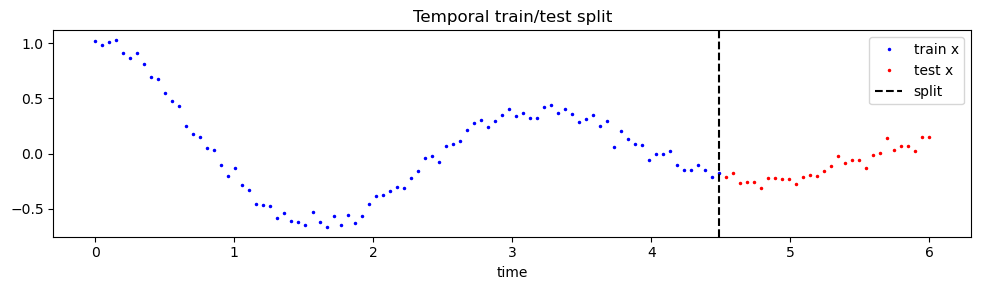

In [3]:
train_data, test_data = ude.train_test_split(data, test_fraction=0.25)
print(f'Train: {len(train_data)} rows  |  Test: {len(test_data)} rows')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(train_data['time'], train_data['x'], 'b.', ms=3, label='train x')
ax.plot(test_data['time'],  test_data['x'],  'r.', ms=3, label='test x')
ax.axvline(train_data['time'].iloc[-1], color='k', ls='--', label='split')
ax.set_xlabel('time'); ax.legend(); ax.set_title('Temporal train/test split')
plt.tight_layout(); plt.show()

## 3 — Baseline Model (No Validation)

Train on `train_data` only. The model has no information about how it performs on
the test window — it may overfit or simply not extrapolate well.

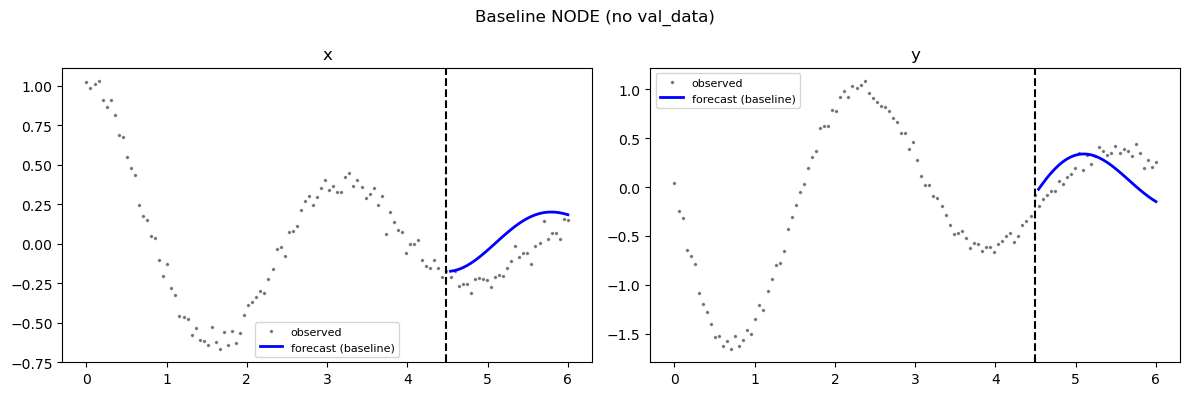

In [4]:
model_base = ude.NODE(train_data, hidden_units=32, hidden_layers=2)
model_base.train(loss='derivative_matching', epochs=300, verbose=False)

fc_base = model_base.forecast(steps=len(test_data))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['x', 'y']):
    ax.plot(data['time'], data[col], 'k.', ms=3, alpha=0.4, label='observed')
    ax.plot(fc_base['time'], fc_base[col], 'b-', lw=2, label='forecast (baseline)')
    ax.axvline(train_data['time'].iloc[-1], color='k', ls='--')
    ax.set_title(col); ax.legend(fontsize=8)
plt.suptitle('Baseline NODE (no val_data)'); plt.tight_layout(); plt.show()

## 4 — Training with `val_data`

Passing `val_data` causes the trainer to compute validation loss every `val_interval`
epochs and store it in `model.train_history_`. This lets us see whether the model is
overfitting before training finishes.

In [5]:
model_val = ude.NODE(train_data, hidden_units=32, hidden_layers=2)
model_val.train(
    loss='derivative_matching', epochs=500,
    val_data=test_data, val_interval=5,
    verbose=False,
)
print('train_history_ keys:', list(model_val.train_history_.keys()))
print('val_loss entries:    ', len(model_val.train_history_['val_loss']))

train_history_ keys: ['train_loss', 'val_loss', 'val_epochs']
val_loss entries:     100


### Plot training and validation loss

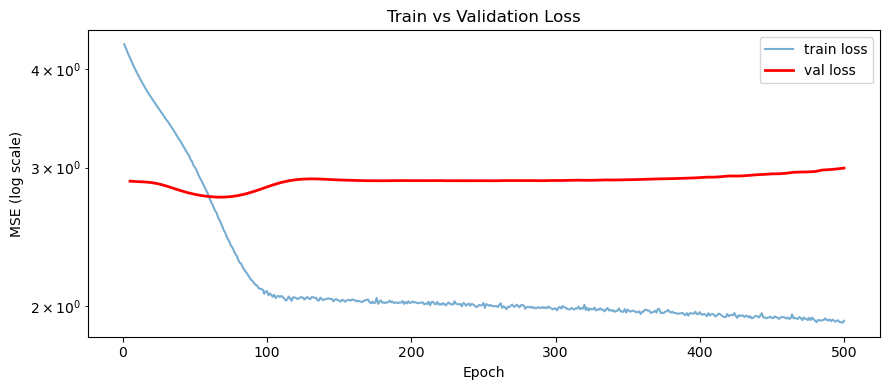

Final train loss: 1.915173
Final val loss:   2.995168


In [6]:
history = model_val.train_history_
epochs_train = range(1, len(history['train_loss']) + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(epochs_train, history['train_loss'], alpha=0.6, label='train loss')
ax.semilogy(history['val_epochs'], history['val_loss'], 'r-', lw=2, label='val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log scale)')
ax.legend(); ax.set_title('Train vs Validation Loss')
plt.tight_layout(); plt.show()

print('Final train loss:', f"{history['train_loss'][-1]:.6f}")
print('Final val loss:  ', f"{history['val_loss'][-1]:.6f}")

## 5 — Val-Based Early Stopping

Set `patience=N` to stop training when validation loss does not improve for `N`
consecutive val epochs. The **best weights** are automatically restored on stopping.

In [7]:
model_es = ude.NODE(train_data, hidden_units=32, hidden_layers=2)
model_es.train(
    loss='derivative_matching', epochs=1000,
    val_data=test_data, val_interval=5, patience=30,
    verbose=True,
)
print('Epochs actually run:', len(model_es.train_history_['train_loss']))

Epoch    50/1000  loss=2.845664  val_loss=2.727015


Epoch   100/1000  loss=2.057403  val_loss=2.849765
Epoch   150/1000  loss=2.030470  val_loss=2.872090


Epoch   200/1000  loss=1.994997  val_loss=2.863771
Early stopping at epoch 205. Best val loss: 2.726727
Epochs actually run: 205


## 6 — Compute Test-Set Metrics

All four metric functions return a `dict` with one entry per state column plus a
`"mean"` key averaging across states.

In [8]:
fc_es = model_es.forecast(steps=len(test_data))
min_len = min(len(fc_es), len(test_data))
obs  = test_data.iloc[:min_len].reset_index(drop=True)
pred = fc_es.iloc[:min_len].reset_index(drop=True)
state_cols = ['x', 'y']

print('MSE:  ', ude.mse(obs[state_cols],    pred[state_cols]))
print('RMSE: ', ude.rmse(obs[state_cols],   pred[state_cols]))
print('MAE:  ', ude.mae(obs[state_cols],    pred[state_cols]))
print('R²:   ', ude.r2_score(obs[state_cols], pred[state_cols]))

MSE:   {'x': 0.005385675383105643, 'y': 0.009323134726933434, 'mean': 0.007354405055019539}
RMSE:  {'x': 0.07338716088734898, 'y': 0.09655638107827692, 'mean': 0.08575782795185252}
MAE:   {'x': 0.06056776425465848, 'y': 0.08067148877096694, 'mean': 0.07061962651281271}
R²:    {'x': 0.7173871332872828, 'y': 0.6924982877908906, 'mean': 0.7049427105390866}


### `score()` dispatcher

Prefer `score()` when the metric is a variable — e.g. when running comparisons in a loop.

In [9]:
for metric in ['mse', 'rmse', 'mae', 'r2_score']:
    s = ude.score(obs[state_cols], pred[state_cols], metric=metric)
    print(f'{metric:>10s}  mean={s["mean"]:.4f}   x={s["x"]:.4f}  y={s["y"]:.4f}')

       mse  mean=0.0074   x=0.0054  y=0.0093
      rmse  mean=0.0858   x=0.0734  y=0.0966
       mae  mean=0.0706   x=0.0606  y=0.0807
  r2_score  mean=0.7049   x=0.7174  y=0.6925


## 7 — NODE vs CustomDerivatives

We supply the known restoring force (`-ω²x`) but let the NN learn the damping term
`-2γy`. This injects partial knowledge without requiring the full equation.

In [10]:
import torch

def osc_known(u, p, t):
    x, y_ = u[0], u[1]
    return torch.stack([
        y_,                  # dx/dt = y  (known)
        -omega**2 * x,       # -ω²x        (known restoring force)
        # damping -2γy is unknown — learned by the NN
    ])

model_cd = ude.CustomDerivatives(
    train_data, osc_known,
    init_params={},   # no mechanistic parameters to learn here
    hidden_units=32,
)
model_cd.train(loss='derivative_matching', epochs=300, verbose=False)

fc_cd = model_cd.forecast(steps=len(test_data))
pred_cd = fc_cd.iloc[:min_len].reset_index(drop=True)

rmse_node = ude.rmse(obs[state_cols], pred[state_cols])['mean']
rmse_cd   = ude.rmse(obs[state_cols], pred_cd[state_cols])['mean']

print(f'NODE RMSE (mean):              {rmse_node:.4f}')
print(f'CustomDerivatives RMSE (mean): {rmse_cd:.4f}')

NODE RMSE (mean):              0.0858
CustomDerivatives RMSE (mean): 0.1697


## Key Takeaways

- **`train_test_split`** preserves temporal order; always split before training.
- **`val_data`** in `train()` tracks generalisation loss without modifying the model.
- **`train_history_`** persists across multiple `train()` calls and accumulates all phases.
- **`patience`** stops training at the best validation checkpoint — not the last epoch.
- **`mse`, `rmse`, `mae`, `r2_score`** all accept DataFrames or arrays and return `{state: val, 'mean': val}`.
- Adding partial mechanistic knowledge via `CustomDerivatives` typically improves generalisation on the test window.